In [117]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#importing models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [118]:
#loading the dataset for pandas
import pandas as pd

df = pd.read_csv("train.csv")

#shows the first 5 rows of the dataset
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [119]:
#checking for missing values
print(X.isnull().sum())

ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
                          ..
Dependents_3+              0
Education_Not Graduate     0
Self_Employed_Yes          0
Property_Area_Semiurban    0
Property_Area_Urban        0
Length: 627, dtype: int64


In [120]:
#fills in the missing values with the most common one for catagorical values.
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

##fills in the missing values with the mean for numerical values.
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())

In [121]:
#chacks for missing values again and confirms there are none
print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [122]:
# converts catogorical values into numerical ones 
df_encoded = pd.get_dummies(df, drop_first=True)

# Identify the column with the loan status which is the target column 
target_col = [col for col in df_encoded.columns if "Loan_Status" in col][0]

# seperating the features and the target variable 
X = df_encoded.drop([target_col, 'Loan_ID'], axis=1, errors='ignore')
y = df_encoded[target_col]


print(X.dtypes)

ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
                            ...   
Dependents_3+                 bool
Education_Not Graduate        bool
Self_Employed_Yes             bool
Property_Area_Semiurban       bool
Property_Area_Urban           bool
Length: 627, dtype: object


In [123]:
#split data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [124]:
#training the logistic regression model
lr = LogisticRegression(max_iter=50000)
lr.fit(X_train, y_train)
#make predictions on the test data
y_pred_lr = lr.predict(X_test)

In [125]:
#traing the decison tree model 
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
#prediction 
y_pred_dt = dt.predict(X_test)

In [126]:
#training random forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
#prediction
y_pred_rf = rf.predict(X_test)

In [127]:

#evaluating model performance using accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)
#printing accuracy for each model 
print("Logistic Regression:", acc_lr)
print("Decision Tree:", acc_dt)
print("Random Forest:", acc_rf)

Logistic Regression: 0.7886178861788617
Decision Tree: 0.6829268292682927
Random Forest: 0.7886178861788617


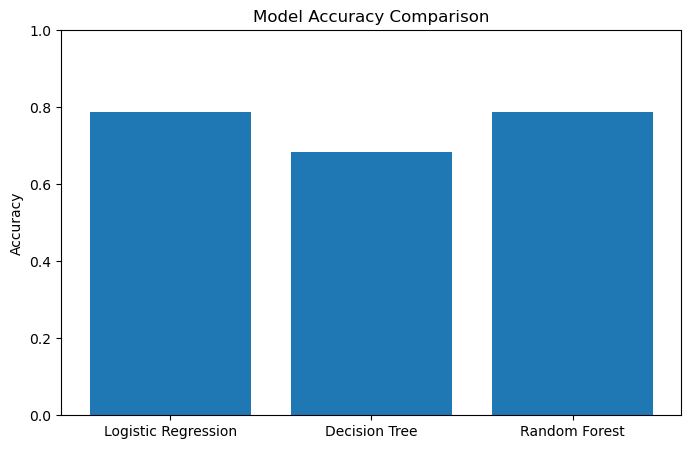

In [128]:
#comparing the performance the 3 models used 
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [acc_lr, acc_dt, acc_rf]
#graphing 
plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

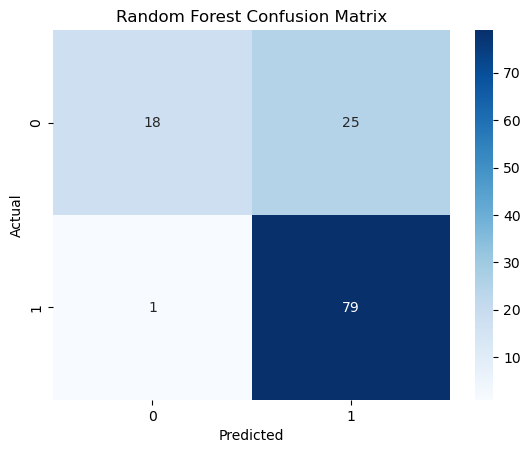

In [129]:
#confusion matrix to evaluate the prediction performance
cm_rf = confusion_matrix(y_test, y_pred_rf)

#visualization
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

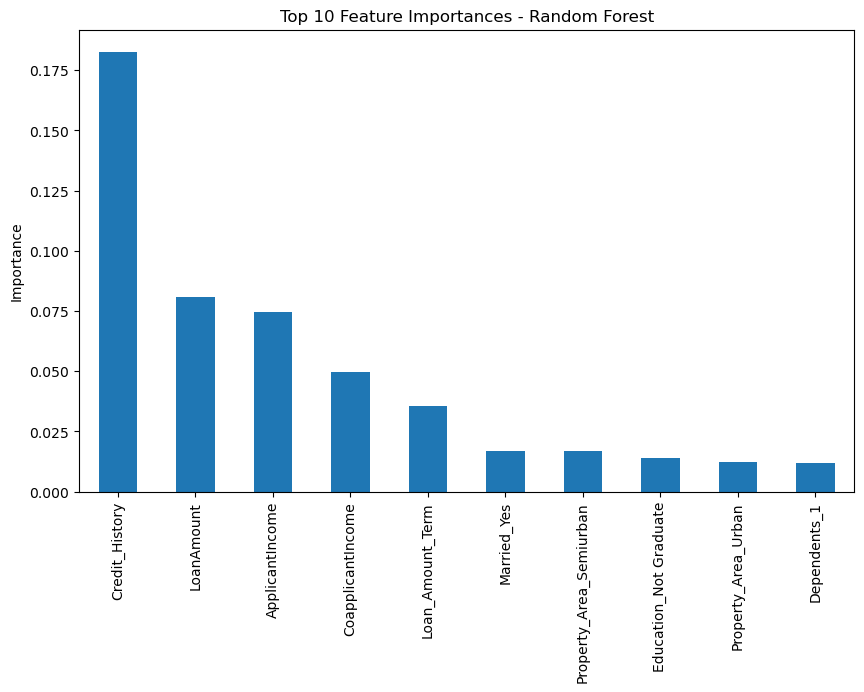

In [130]:
# identifying important features influencing loan decision in using random forest
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
#10 importanat features
top_features = feature_importance.sort_values(ascending=False).head(10)

#plotting
plt.figure(figsize=(10,6))
top_features.plot(kind='bar')
plt.title("Top 10 Feature Importances - Random Forest")
plt.ylabel("Importance")
plt.show()

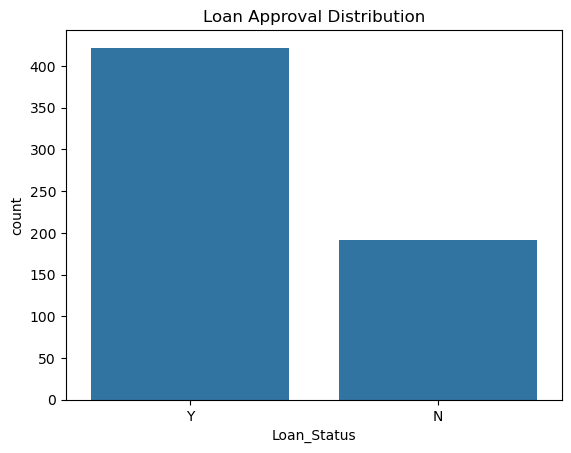

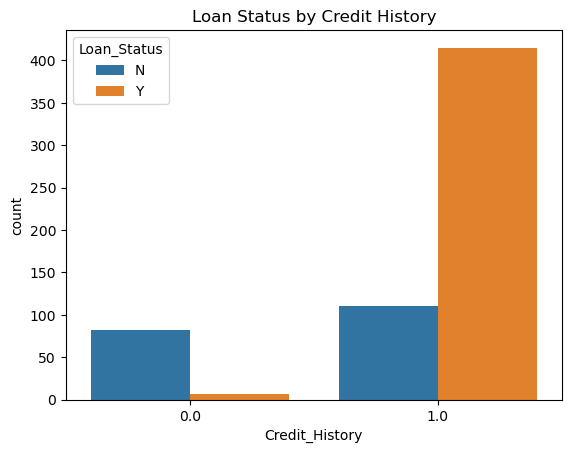

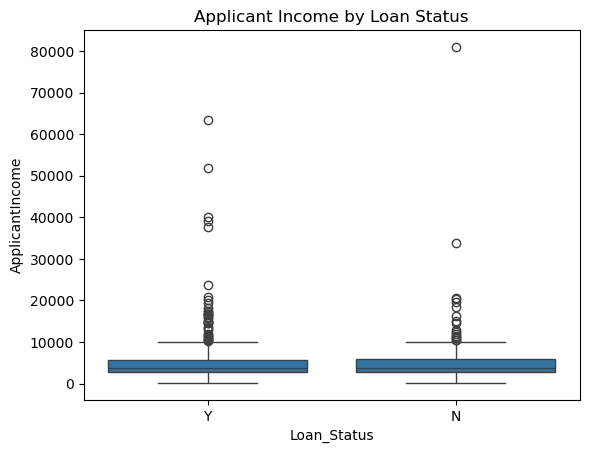

In [133]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Loan Status by Credit History")
plt.show()

sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Applicant Income by Loan Status")
plt.show()


In [ ]:
feature_importance.sort_values(ascending=False)


Credit_History       0.182682
LoanAmount           0.080676
ApplicantIncome      0.074638
CoapplicantIncome    0.049762
Loan_Amount_Term     0.035495
                       ...   
Loan_ID_LP001900     0.000000
Loan_ID_LP002444     0.000000
Loan_ID_LP002446     0.000000
Loan_ID_LP002448     0.000000
Loan_ID_LP001790     0.000000
Length: 627, dtype: float64